Requisition's Generator

In [5]:
# To activate auto reloading of the modules
%load_ext autoreload

# To reload all modules before executing each cell
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import numpy as np
import time
import random
import matplotlib.pyplot as plt

from req_generator import Uniform, zipf
from cache import LRU, QLRU, LFU
from monitor import Monitor

np.random.seed(0)
random.seed(0)

Parameters

In [7]:
f = 6
t = 1000
alpha = 0.8
c = 2
initial_state = list(random.sample(range(f), c))
q = 0.001

In [ ]:
num_servers = 2

# def get_server(file_id, total_files, total_servers):

#     server_size = total_files // total_servers

#     server_id = file_id // server_size

#     return min(server_id, total_servers - 1)


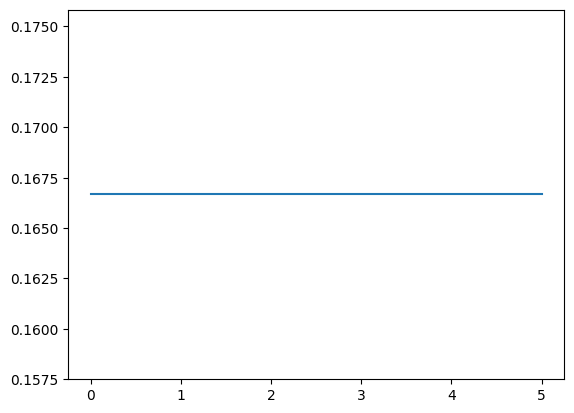

In [10]:
popularities = Uniform(f)
req = np.random.choice(f,t,p=popularities)

plt.plot([i for i in range(f)], popularities)

plt.show()

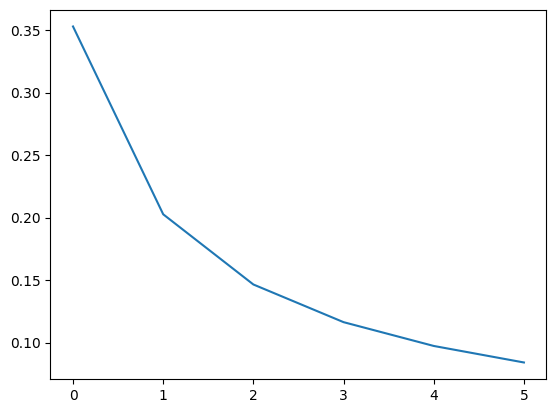

In [11]:
popularities = zipf(alpha, f)
req = np.random.choice(f, t, p=popularities)

plt.plot([i for i in range(f)], popularities)

plt.show()

In [12]:
print(popularities)
print(sum(popularities[:c]))

[0.35286928 0.20267018 0.14652673 0.11640345 0.09737284 0.08415751]
0.5555394683671806


CACHE

LRU

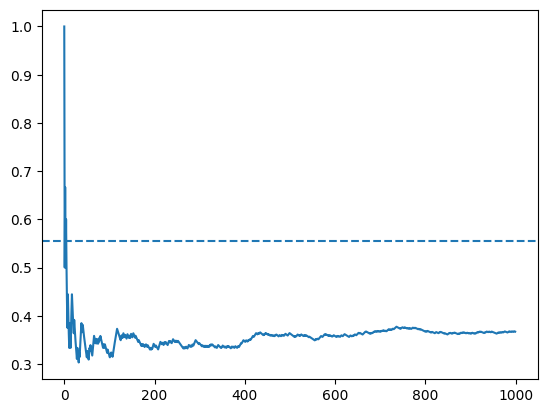

LRU's Hit Rate: 36.70%
Cargas (Omega): [374. 259.]
Jain's Fairness Index: 0.9680
Ângulo do Vetor Ω: 34.70 graus


In [23]:
monitor = Monitor(num_servers, f)

lru = LRU(initial_state, c)
monitor.plot_hit_rate(lru, req, popularities, c, "LRU")


QLRU

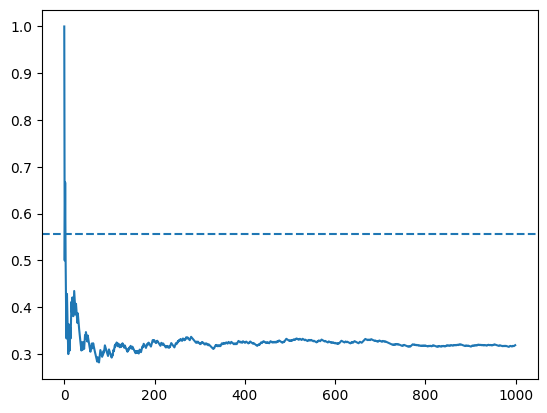

qLRU's Hit Rate: 31.90%
Cargas (Omega): [352. 329.]
Jain's Fairness Index: 0.9989
Ângulo do Vetor Ω: 43.07 graus


In [24]:
qlru = QLRU(initial_state, c, q)
monitor.plot_hit_rate(qlru, req, popularities, c, "qLRU")

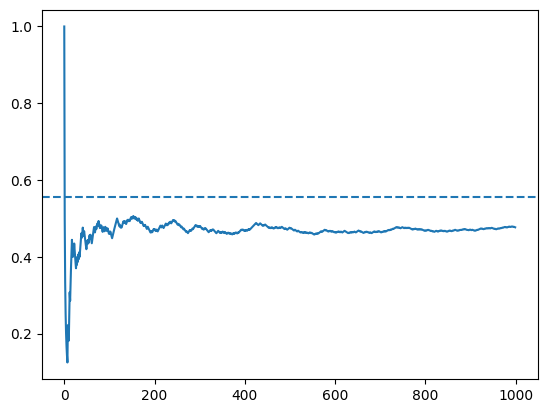

LFU's Hit Rate: 47.70%
Cargas (Omega): [244. 279.]
Jain's Fairness Index: 0.9955
Ângulo do Vetor Ω: 48.83 graus


In [25]:
lfu = LFU(initial_state, c, f)
monitor.plot_hit_rate(lfu, req, popularities, c, "LFU")